In [122]:
!pip install pyspark --quiet
print("PySpark installation complete!")

PySpark installation complete!


In [123]:
from pyspark.sql import SparkSession
#Spark session is the single entry point to all PySpark functionality
from pyspark.sql import functions as f
from pyspark.sql.functions import year,month,to_date,col,round as spark_round

import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [124]:
spark = SparkSession.builder \
        .appName('Day4_BigData_Sales') \
        .config('spark.sql.adaptive.enabled','true') \
        .getOrCreate()

print(f"Spark Version : {spark.version}")
print(f"Spark App Name : {spark.sparkContext.appName}")
print("SparkSession : Active")

Spark Version : 4.0.2
Spark App Name : Day4_BigData_Sales
SparkSession : Active


In [125]:
df_bronze = spark.read \
            .option('header','true') \
            .option('inferSchema','true') \
            .csv('/content/drive/MyDrive/intren/large_sales_data.csv')

print("BRONZE LAYER COMPLETED")
print(f"Rows : {df_bronze.count()}")
print(f"Columns : {len(df_bronze.columns)}")
print(f"Names : {df_bronze.columns}")
df_bronze.printSchema()

BRONZE LAYER COMPLETED
Rows : 5000
Columns : 13
Names : ['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'revenue', 'order_date', 'city', 'region', 'sales_rep', 'payment_method', 'order_status']
root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



In [126]:
print("First 5 rows: ")
df_bronze.show(5,truncate=False)

print("Basic statistics for numeric columns :")
df_bronze.select('quantity','unit_price','revenue').describe().show()

First 5 rows: 
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|product   |category   |quantity|unit_price|revenue|order_date|city     |region|sales_rep  |payment_method  |order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|1001    |Sneha Reddy  |Monitor   |Electronics|12      |22000     |264000 |2023-05-21|Mumbai   |West  |Meera Patel|UPI             |Delivered   |
|1002    |Ramesh Kumar |Printer   |Electronics|10      |12000     |120000 |2023-08-05|Delhi    |North |Anil Sharma|Credit Card     |Shipped     |
|1003    |Rahul Mishra |Mouse     |Accessories|10      |800       |8000   |2023-01-14|Ahmedabad|West  |Meera Patel|Cash on Delivery|Shipped     |
|1004    |Suresh Rao   |Tablet    |Electronics|5       |32000     |160000 |2023-01-04|Surat    |West  |Ravi K

In [127]:
df_bronze.write.mode('overwrite') \
        .parquet('/content/drive/MyDrive/intren/bronze_sales_data.parquet')
print("Bronze parquet saved")

import os

def get_dir_size(path):
  if os.path.isfile(path):
    return os.path.getsize(path) / 1024
  total = 0
  for dirpath, dirnames, filenames in os.walk(path):
    for f in filenames:
      total += os.path.getsize(os.path.join(dirpath,f))
  return total/1024

# Update paths to reflect the sales data
new_csv_path = '/content/drive/MyDrive/intren/large_sales_data.csv'
new_parquet_path = '/content/drive/MyDrive/intren/bronze_sales_data.parquet'

csv_size = get_dir_size(new_csv_path)
parquet_size = get_dir_size(new_parquet_path)
reduction = (1 - parquet_size/csv_size) * 100

print(f"CSV file size ({os.path.basename(new_csv_path)}): {csv_size:.2f} KB")
print(f"Parquet file size ({os.path.basename(new_parquet_path)}): {parquet_size:.2f} KB")
print(f"Reduction in size: {reduction:.2f}%")

Bronze parquet saved
CSV file size (large_sales_data.csv): 529.31 KB
Parquet file size (bronze_sales_data.parquet): 55.10 KB
Reduction in size: 89.59%


In [128]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [129]:
df_silver = df_bronze \
            .dropDuplicates() \
            .dropna(subset=['order_id','product','revenue'])

df_silver = df_silver.withColumn(
    'order_date',
    to_date(col('order_date'),'yyyy-MM-dd')
)

df_silver = df_silver \
            .withColumn('order_year',year(col('order_date'))) \
            .withColumn('order_month',month(col('order_date')))

df_silver = df_silver.withColumn(
    'revenue_category',
    f.when(col('revenue') > 40000, "High")
    .when(col('revenue') > 10000, "Medium")
    .otherwise("Low")
)

print("SILVER LAYER COMPLETED")
print(f"Rows : {df_silver.count()}")
print("New columns  added : order_year,order_month,revenue_category")
df_silver.select('product','revenue','order_year','order_month','revenue_category').show(5,truncate=False)

SILVER LAYER COMPLETED
Rows : 5000
New columns  added : order_year,order_month,revenue_category
+--------+-------+----------+-----------+----------------+
|product |revenue|order_year|order_month|revenue_category|
+--------+-------+----------+-----------+----------------+
|Keyboard|13200  |2023      |2          |Medium          |
|Webcam  |17500  |2023      |1          |Medium          |
|Speaker |58500  |2023      |4          |High            |
|Keyboard|9600   |2023      |12         |Low             |
|Laptop  |180000 |2023      |8          |High            |
+--------+-------+----------+-----------+----------------+
only showing top 5 rows


In [130]:
df_silver.write \
        .mode('overwrite') \
        .parquet('/content/drive/MyDrive/intren/silver_sales_data.parquet')

print(f"Silver size : {get_dir_size('/content/drive/MyDrive/intren/silver_sales_data.parquet'):.1f} KB")

df_verify = spark.read.parquet('/content/drive/MyDrive/intren/silver_sales_data.parquet')
print(f"Read-back rows : {df_verify.count()}")
print()
df_verify.printSchema()

Silver size : 59.8 KB
Read-back rows : 5000

root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_month: integer (nullable = true)
 |-- revenue_category: string (nullable = true)



In [131]:
top5city = df_silver.groupBy('city') \
                .agg(f.sum('revenue').alias('total_revenue')) \
                .orderBy(f.desc('total_revenue')) \
                .limit(5)

top5city.show()

+-------+-------------+
|   city|total_revenue|
+-------+-------------+
|Chennai|     52576700|
|  Surat|     52157500|
|  Delhi|     51927100|
|   Pune|     51882300|
|Kolkata|     50547700|
+-------+-------------+



In [132]:
top_products = df_silver \
     .groupBy('product') \
     .agg(
         f.sum('revenue').alias('total_revenue'),
         f.count('order_id').alias('num_orders'),
         f.avg('revenue').alias('avg_order_revenue')
     ) \
     .orderBy('total_revenue',ascending=False) \
     .limit(5)
print('===TOP 5 PRODUCTS===')
top_products.show(truncate = True)

===TOP 5 PRODUCTS===
+-------+-------------+----------+------------------+
|product|total_revenue|num_orders| avg_order_revenue|
+-------+-------------+----------+------------------+
| Laptop|    182700000|       502|363944.22310756973|
| Tablet|    135104000|       532| 253954.8872180451|
|Monitor|     82126000|       481|170740.12474012474|
|Printer|     44544000|       488| 91278.68852459016|
|Speaker|     16317000|       470| 34717.02127659575|
+-------+-------------+----------+------------------+



In [133]:
top_products = df_silver \
     .groupBy('region') \
     .agg(
         f.sum('revenue').alias('total_revenue'),
         f.count('order_id').alias('total_orders'),
         f.count_distinct('customer_name').alias('unique_customers')
     ) \
     .orderBy('total_revenue',ascending=False) \
     .limit(5)
print('===TOP 5 REGION===')
top_products.show(truncate = True)

===TOP 5 REGION===
+------+-------------+------------+----------------+
|region|total_revenue|total_orders|unique_customers|
+------+-------------+------------+----------------+
|  West|    198275600|        2021|              15|
| South|    147145900|        1483|              15|
| North|     99878400|         995|              15|
|  East|     50547700|         501|              15|
+------+-------------+------------+----------------+



In [134]:
distinct_customers_by_region = df_silver \
        .groupBy('region') \
        .agg(
            f.collect_set('customer_name').alias('distinct_customer_names')
        ) \
        .orderBy('region', ascending = True)

print("=== Distinct Customers by Region ===")
distinct_customers_by_region.show(truncate=False)

=== Distinct Customers by Region ===
+------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|region|distinct_customer_names                                                                                                                                                                            |
+------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|East  |[Meera Joshi, Ananya Das, Kiran Kumar, Vikram Iyer, Pooja Gupta, Ramesh Kumar, Rahul Mishra, Divya Singh, Arjun Nair, Sneha Reddy, Priya Patel, Suresh Rao, Kavya Nambiar, Amit Verma, Tanvi Mehta]|
|North |[Meera Joshi, Ananya Das, Kiran Kumar, Vikram Iyer, Pooja Gupta, Ramesh Kumar, Rahul Mishra, Divya Singh, Arjun Nair, Sneha Reddy, Priy

In [135]:
monthly_revenue_trend = df_silver \
    .groupBy('order_month') \
    .agg(
        f.sum('revenue').alias('monthly_revenue'),
        f.count('order_id').alias('monthly_orders')
    ) \
    .orderBy('order_month')

print("=== Monthly Revenue Trend ===")
monthly_revenue_trend.show(truncate=False)


=== Monthly Revenue Trend ===
+-----------+---------------+--------------+
|order_month|monthly_revenue|monthly_orders|
+-----------+---------------+--------------+
|1          |41068200       |423           |
|2          |34485400       |375           |
|3          |40031200       |451           |
|4          |38857100       |390           |
|5          |39984500       |423           |
|6          |40707400       |390           |
|7          |42640700       |405           |
|8          |43718500       |418           |
|9          |37640200       |398           |
|10         |47839000       |479           |
|11         |44577100       |419           |
|12         |44298300       |429           |
+-----------+---------------+--------------+



In [136]:
monthly_revenue_trend_with_names = df_silver \
    .withColumn('month_name', f.date_format(f.col('order_date'), 'MMMM')) \
    .groupBy('order_month', 'month_name') \
    .agg(
        f.sum('revenue').alias('monthly_revenue'),
        f.count('order_id').alias('monthly_orders')
    ) \
    .orderBy('order_month') \
    .select('order_month', 'month_name', 'monthly_revenue', 'monthly_orders')

In [137]:
gold_region = top_products
gold_region.write.mode('overwrite').parquet('/content/drive/MyDrive/intren/sales_gold_region.parquet')
print('Gold Parquet 1 saved: sales_gold_region.parquet')

gold_product = df_silver \
               .groupBy('product', 'category') \
               .agg(
                   f.sum('revenue').alias('total_revenue'),
                   f.count('order_id').alias('order_count'),
                   spark_round(f.avg('revenue'),2).alias('avg_revenue'),
                   f.max('revenue').alias('largest_order')
               ) \
               .orderBy('total_revenue', ascending = False)

gold_product.write.mode('overwrite').parquet('/content/drive/MyDrive/intren/sales_gold_product.parquet')
print('Gold Parquet 2 saved: sales_gold_product.parquet')

Gold Parquet 1 saved: sales_gold_region.parquet
Gold Parquet 2 saved: sales_gold_product.parquet


In [138]:
gold_monthly = monthly_revenue_trend_with_names
gold_monthly.write.mode('overwrite').parquet('/content/drive/MyDrive/intren/sales_gold_monthly.parquet')
print('Gold Parquet saved: sales_gold_monthly.parquet')

region_pd=spark.read.parquet('/content/drive/MyDrive/intren/sales_gold_region.parquet').toPandas()
product_pd=spark.read.parquet('/content/drive/MyDrive/intren/sales_gold_product.parquet').toPandas()
monthly_pd=spark.read.parquet('/content/drive/MyDrive/intren/sales_gold_monthly.parquet').toPandas()

print("gold ")
print(f'region_pd : {region_pd.shape}')
print(f'product_pd : {product_pd.shape}')
print(f'monthly_pd : {monthly_pd.shape}')

region_pd=region_pd.sort_values(by='total_revenue',ascending=False)
product_pd=product_pd.sort_values(by='total_revenue',ascending=False)
monthly_pd=monthly_pd.sort_values(by='month_name')

Gold Parquet saved: sales_gold_monthly.parquet
gold 
region_pd : (4, 4)
product_pd : (10, 6)
monthly_pd : (12, 4)


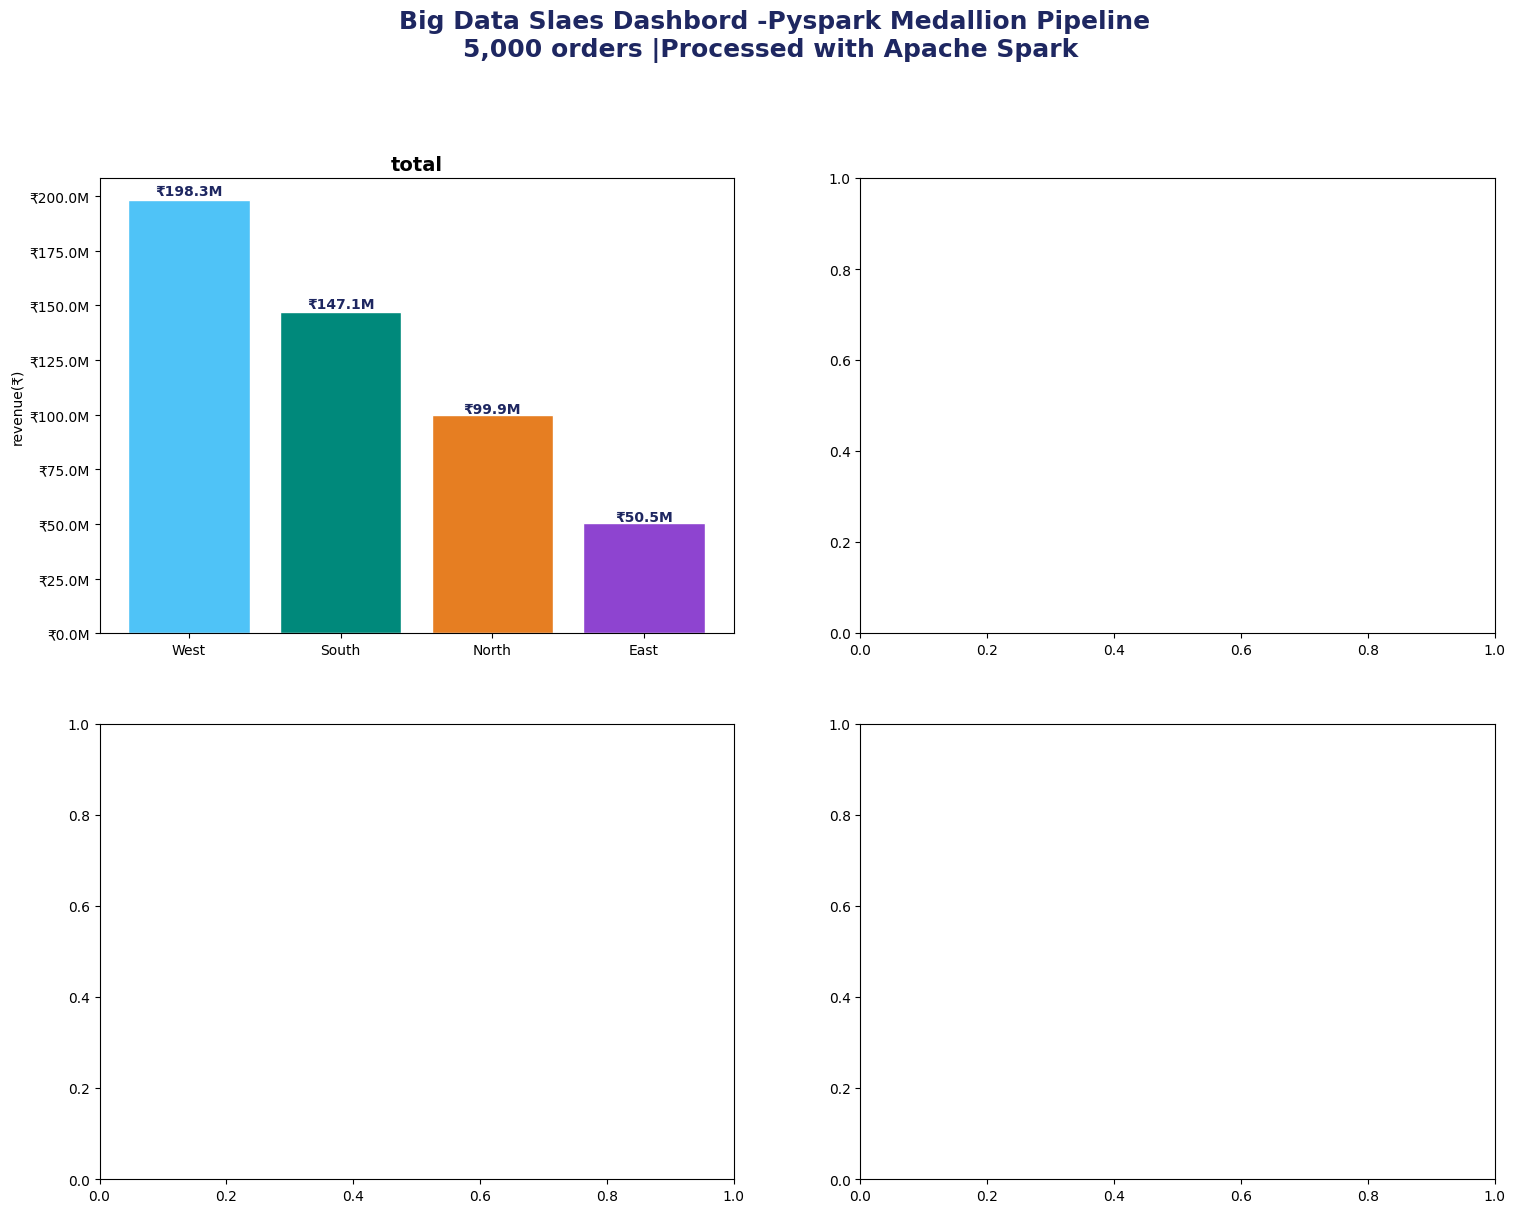

In [139]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('Big Data Slaes Dashbord -Pyspark Medallion Pipeline\n'
'5,000 orders |Processed with Apache Spark ',fontsize=18,fontweight='bold',color='#1E2761',y=1.01)
colors4=['#4fc3F7','#00897B','#E67E22','#8E44D0','#E74C3C']
ax1=axes[0][0]
bars1=ax1.bar(region_pd['region'],region_pd['total_revenue'],color=colors4[:len(region_pd)],edgecolor='white')
for bar in bars1:
  ax1.text(bar.get_x()+bar.get_width()/2,bar.get_height()*1.01,f'₹{bar.get_height()/1e6:.1f}M',ha='center',fontsize=10,fontweight='bold',color='#1E2761')
  ax1.set_title('total',fontsize=14,fontweight='bold')
  ax1.set_ylabel('revenue(₹)')
  ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos:f'₹{x/1e6:.1f}M'))

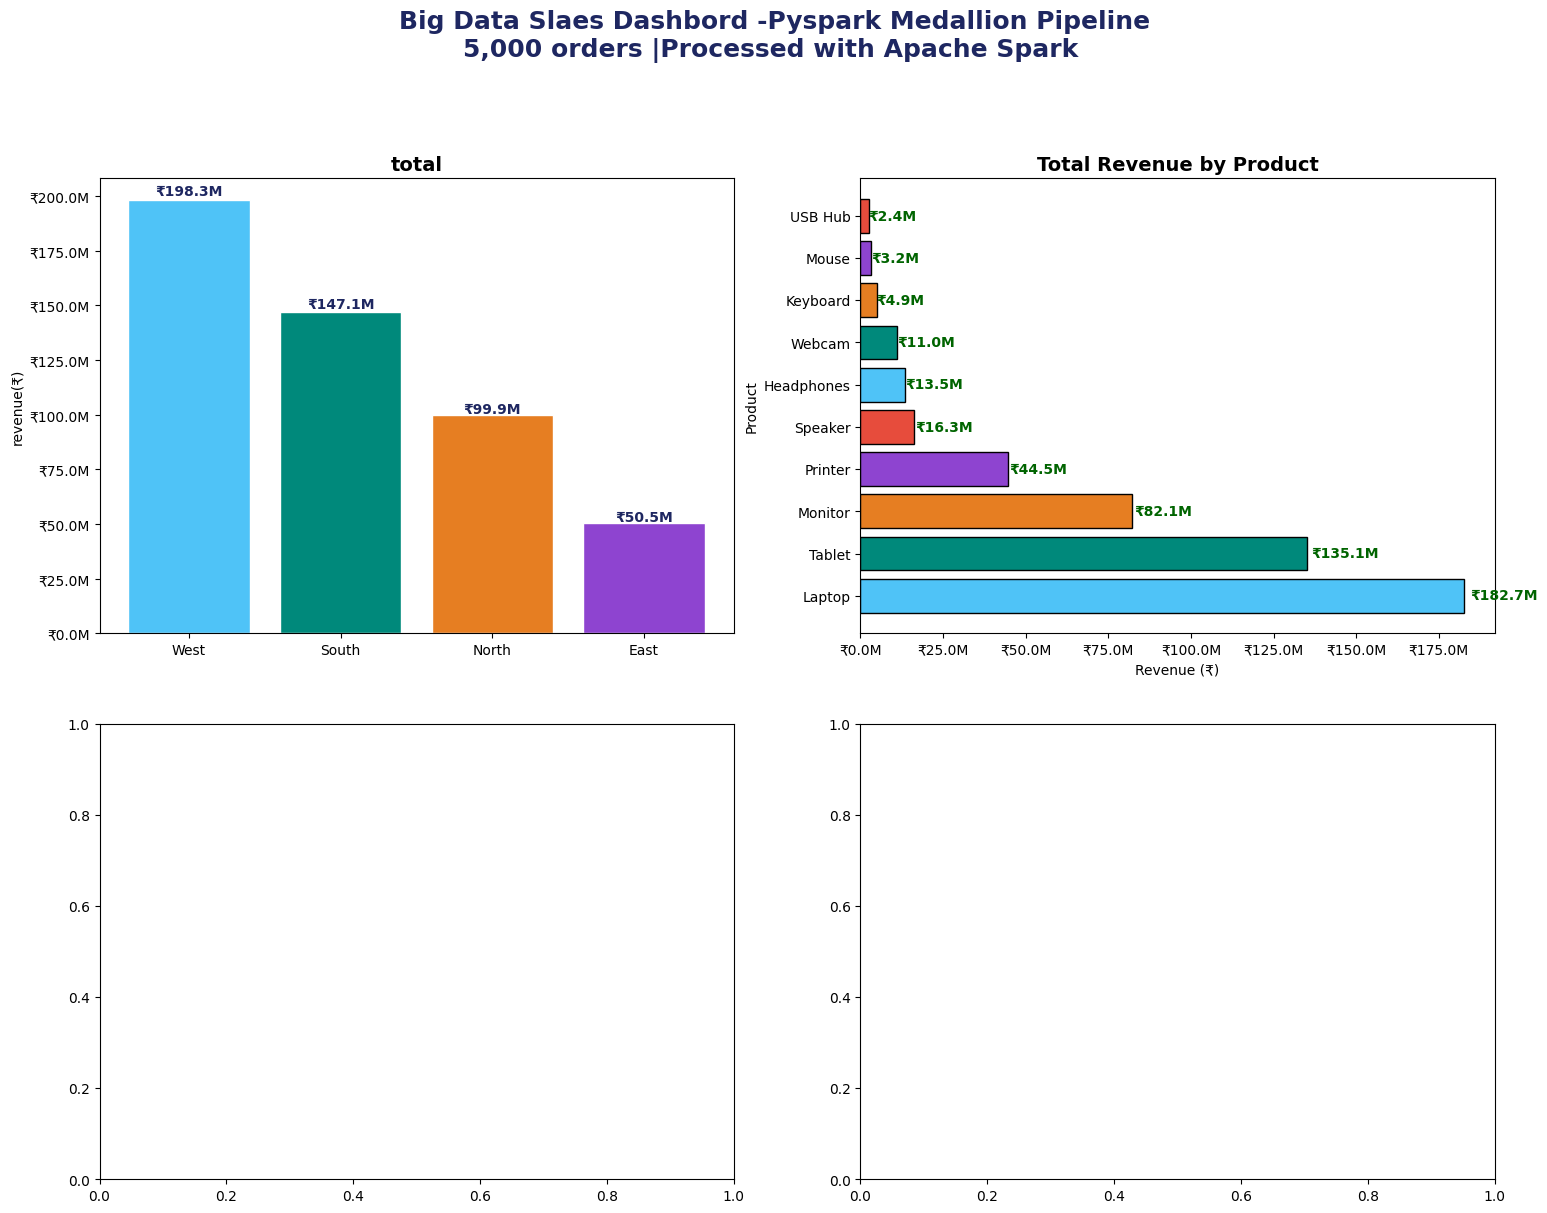

In [140]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('Big Data Slaes Dashbord -Pyspark Medallion Pipeline\n'
'5,000 orders |Processed with Apache Spark ',fontsize=18,fontweight='bold',color='#1E2761',y=1.01)
colors4=['#4fc3F7','#00897B','#E67E22','#8E44D0','#E74C3C']
ax2 = axes[0, 1]
bars2 = ax2.barh(product_pd['product'], product_pd['total_revenue'], color=colors4[:len(product_pd)],edgecolor='black')

for bar in bars2:
  ax2.text(bar.get_x() + bar.get_width()*1.01, bar.get_y() + bar.get_height()/2,
           f"₹{bar.get_width()/1e6 :.1f}M",
           va='center', fontsize=10,fontweight='bold',color='Darkgreen')

ax2.set_title("Total Revenue by Product",fontsize=14,fontweight='bold')
ax2.set_xlabel('Revenue (₹)')
ax2.set_ylabel('Product')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"₹{x/1e6:.1f}M"))
ax1=axes[0][0]
bars1=ax1.bar(region_pd['region'],region_pd['total_revenue'],color=colors4[:len(region_pd)],edgecolor='white')
for bar in bars1:
  ax1.text(bar.get_x()+bar.get_width()/2,bar.get_height()*1.01,f'₹{bar.get_height()/1e6:.1f}M',ha='center',fontsize=10,fontweight='bold',color='#1E2761')
  ax1.set_title('total',fontsize=14,fontweight='bold')
  ax1.set_ylabel('revenue(₹)')
  ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos:f'₹{x/1e6:.1f}M'))

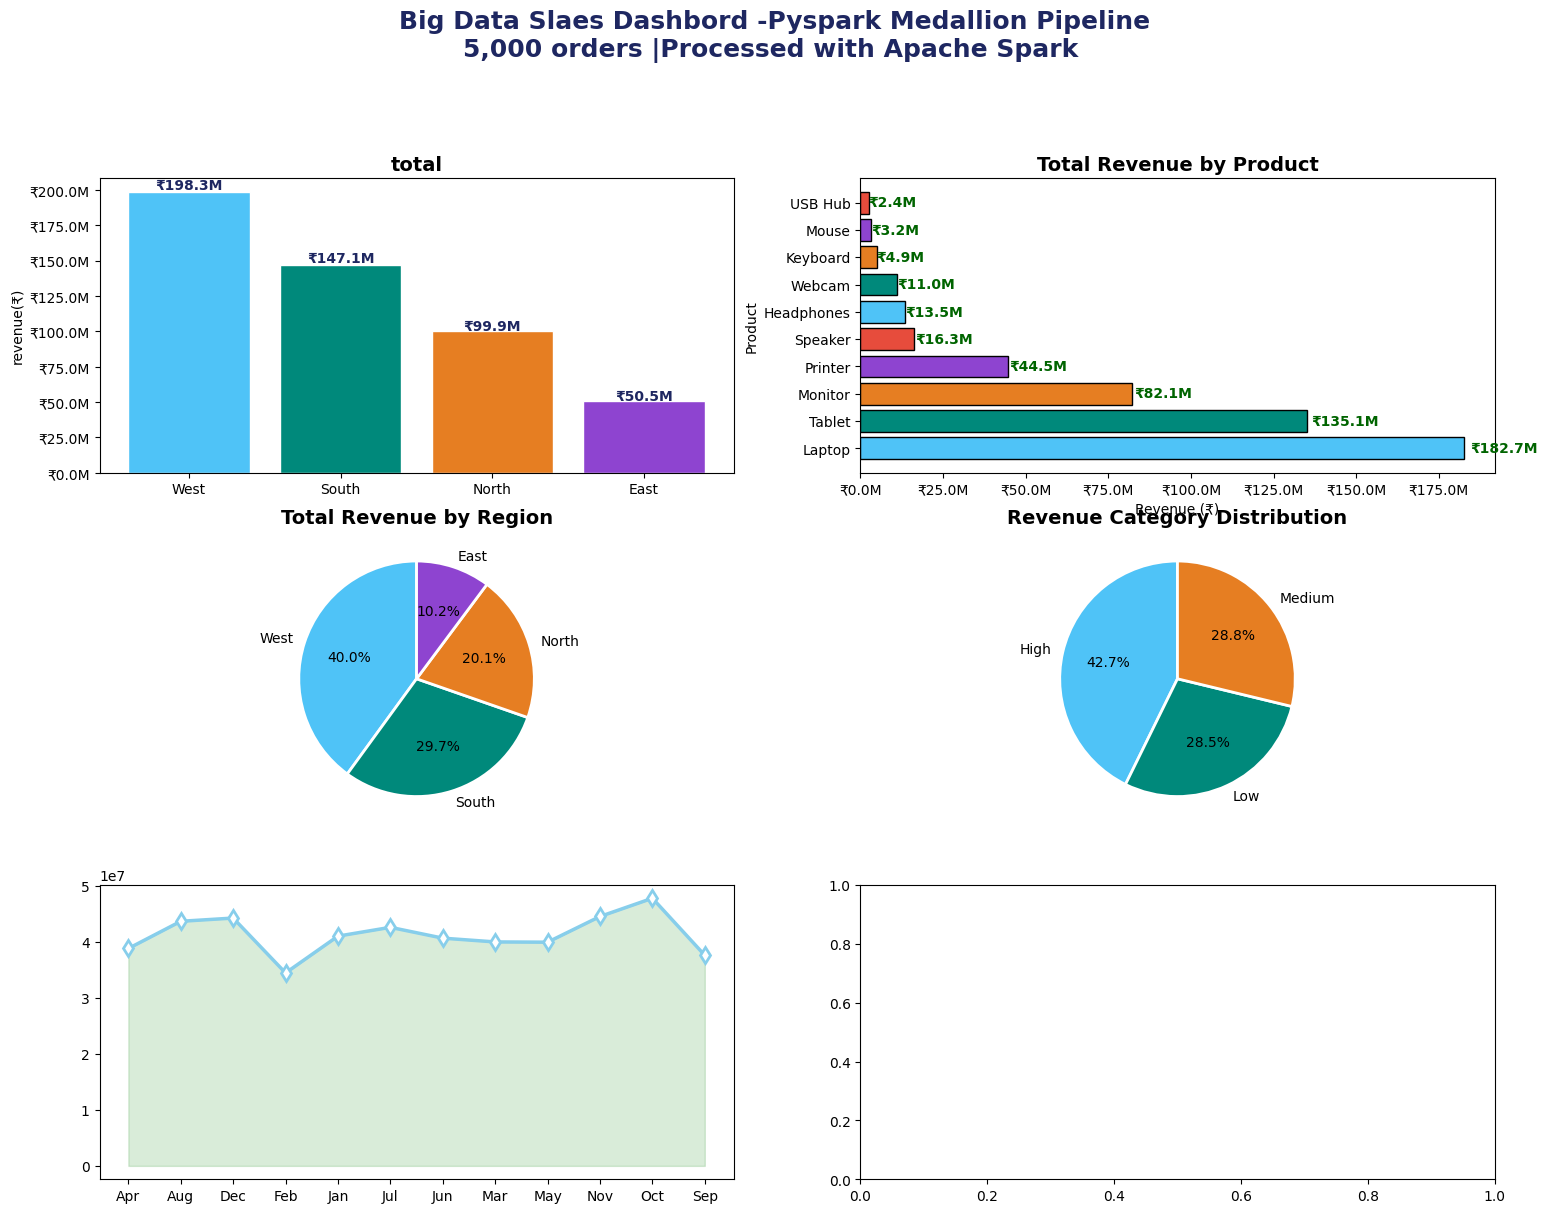

In [154]:
fig, axes = plt.subplots(3, 2, figsize=(18, 13))
fig.suptitle('Big Data Slaes Dashbord -Pyspark Medallion Pipeline\n'
'5,000 orders |Processed with Apache Spark ',fontsize=18,fontweight='bold',color='#1E2761',y=1.01)
colors4=['#4fc3F7','#00897B','#E67E22','#8E44D0','#E74C3C']
ax2 = axes[0, 1]
bars2 = ax2.barh(product_pd['product'], product_pd['total_revenue'], color=colors4[:len(product_pd)],edgecolor='black')

for bar in bars2:
  ax2.text(bar.get_x() + bar.get_width()*1.01, bar.get_y() + bar.get_height()/2,
           f"₹{bar.get_width()/1e6 :.1f}M",
           va='center', fontsize=10,fontweight='bold',color='Darkgreen')

ax2.set_title("Total Revenue by Product",fontsize=14,fontweight='bold')
ax2.set_xlabel('Revenue (₹)')
ax2.set_ylabel('Product')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"₹{x/1e6:.1f}M"))

ax1=axes[0][0]
bars1=ax1.bar(region_pd['region'],region_pd['total_revenue'],color=colors4[:len(region_pd)],edgecolor='white')
for bar in bars1:
  ax1.text(bar.get_x()+bar.get_width()/2,bar.get_height()*1.01,f'₹{bar.get_height()/1e6:.1f}M',ha='center',fontsize=10,fontweight='bold',color='#1E2761')
  ax1.set_title('total',fontsize=14,fontweight='bold')
  ax1.set_ylabel('revenue(₹)')
  ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos:f'₹{x/1e6:.1f}M'))


df_ps = product_pd.groupby('category').agg(Value=('total_revenue', 'sum')).reset_index()
df_ps = df_ps.rename(columns={'category': 'Category'})
ax3 = axes[1, 0]
ax3.pie(
    region_pd['total_revenue'],
    labels=region_pd['region'],
    colors=colors4[:len(region_pd)],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

ax3.set_title("Total Revenue by Region", fontsize=14, fontweight='bold')

ax4 = axes[1, 1]
rev_cat = df_silver.groupBy('revenue_category').count().orderBy('revenue_category').toPandas()
ax4.pie(rev_cat['count'],
        labels=rev_cat['revenue_category'],
        colors=['#4FC3F7','#00897B','#E67E22','#8E44AD','#E74C3C'],
        autopct='%1.1f%%',startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':2})
ax4.set_title('Revenue Category Distribution',fontsize=14,fontweight='bold')
ax5= axes[2,0]
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_labels = [month_names[m-1] for m in monthly_pd['order_month']]
ax5.plot(monthly_labels,monthly_pd['monthly_revenue'],
         marker='d',linewidth=2.5,color='SkyBlue',
         markersize=8,markerfacecolor='white',markeredgewidth=2)
ax5.fill_between(range(len(monthly_labels)),
                 monthly_pd['monthly_revenue'],
                 alpha=0.15,color='green')